# Single-Patient EEG Seizure Detection with Random Forest + Raw EDF Feature Extraction

这个 notebook 是基于你之前的原始数据版代码，重新整理后的 **单病人版本**，核心改动如下：

1. **不再读取 cache**，而是直接从原始 EDF 文件读取数据。
2. **模型改成 Random Forest**，方便输出特征重要性。
3. **增加更实用的特征提取**，包括：
   - band power / relative band power
   - RMS
   - **Line Length**
   - Zero Crossing
   - Peak-to-Peak
   - Hjorth Activity / Mobility / Complexity
   - Spectral Entropy
   - band power ratios
4. **加入特征重要性分析与特征筛选**：
   - `feature_importances_`（MDI）
   - permutation importance（更适合做保留/剔除）
   - 用筛选后的 top-K 特征重新训练并比较结果
5. **不做 LOOCV**，只处理一个 patient，并采用 **按文件分组切分 train/test**，避免相邻 epoch 泄漏。

> 说明：这个 notebook 默认假设你的数据结构与 CHB-MIT 类似，即：
>
> - `DATA_ROOT/chb01/*.edf`
> - `DATA_ROOT/chb01/chb01-summary.txt` 或 `DATA_ROOT/chb01-summary.txt`

## Block 0 — 环境与依赖 / Environment & Imports

In [4]:
import os
import re
import glob
import sys
import subprocess
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Auto-install missing packages
# ------------------------------
def _ensure_package(pkg: str):
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["mne", "scipy", "sklearn"]:
    _ensure_package(_pkg)

import mne
from scipy.signal import butter, filtfilt, welch
from scipy.integrate import simpson

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance
from IPython.display import display

# Optional: mount Google Drive when running in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Not in Colab. Skipping drive mount.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

print("Environment ready.")

Not in Colab. Skipping drive mount.
Environment ready.


## Block 1 — 全局配置 / Global Configuration

In [ ]:
# ============================================================
# 1. Please change these paths/settings before running
# ============================================================
# Colab  DATA_ROOT = "/content/drive/MyDrive/EEGDATA" 
DATA_ROOT = r"D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0"  
PATIENT_ID = "chb01"                           # <-- 只跑一个病人
DEBUG_MAX_FILES = None                         # e.g. 5 for quick debugging, or None for all files

# ============================================================
# 2. EEG segmentation & preprocessing
# ============================================================
EPOCH_LEN_S = 2.0
MAIN_BANDPASS = (0.5, 30.0)

# Standard EEG bands
BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
}

# ============================================================
# 3. Train/test split (file-level split inside one patient)
# ============================================================
TEST_SIZE = 0.25

# ============================================================
# 4. Random Forest hyperparameters
# ============================================================
RF_PARAMS = {
    "n_estimators": 400,
    "max_depth": None,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
    "oob_score": True,                 # 用 OOB 概率做阈值选择
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

# ============================================================
# 5. Feature selection settings
# ============================================================
TOP_K_FEATURES = 60                    # 用 permutation importance 排名前 K 的特征重训
PERM_N_REPEATS = 10
PERM_SCORING = "average_precision"     # 类别不平衡时比 accuracy 更合适

# ============================================================
# 6. Output
# ============================================================
OUTPUT_DIR = os.path.join(DATA_ROOT, "_rf_single_patient_results", PATIENT_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"PATIENT_ID = {PATIENT_ID}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

PATIENT_ID = chb01
OUTPUT_DIR = D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\_rf_single_patient_results\chb01


## Block 2 — 路径解析与 Summary 解析 / Path Utilities & Summary Parsing

In [6]:
def infer_patient_paths(patient_id: str, data_root: str) -> Tuple[str, str]:
    """
    尝试自动推断:
    1) 病人目录
    2) summary 文件路径
    """
    patient_dir_candidates = [
        os.path.join(data_root, patient_id),
        os.path.join(data_root, patient_id.upper()),
    ]
    patient_dir = next((p for p in patient_dir_candidates if os.path.isdir(p)), patient_dir_candidates[0])

    summary_candidates = [
        os.path.join(patient_dir, f"{patient_id}-summary.txt"),
        os.path.join(patient_dir, f"{patient_id.upper()}-summary.txt"),
        os.path.join(data_root, f"{patient_id}-summary.txt"),
        os.path.join(data_root, f"{patient_id.upper()}-summary.txt"),
        os.path.join(patient_dir, "summary.txt"),
    ]
    summary_path = next((p for p in summary_candidates if os.path.exists(p)), summary_candidates[0])
    return patient_dir, summary_path


def list_edf_files(folder: str, max_files: Optional[int] = None) -> List[str]:
    """Return sorted EDF file list."""
    edf_paths = sorted(glob.glob(os.path.join(folder, "*.edf")))
    if not edf_paths:
        raise FileNotFoundError(f"No EDF files found in: {folder}")
    if max_files is not None:
        edf_paths = edf_paths[:max_files]
    return edf_paths


def parse_summary_to_dict(summary_path: str) -> Dict[str, List[Tuple[float, float]]]:
    """
    Parse CHB-MIT style summary file.
    Return:
        {
            "chb01_03.edf": [(start_s, end_s), ...],
            ...
        }
    """
    if not os.path.exists(summary_path):
        print(f"[WARN] Summary file not found: {summary_path}")
        return {}

    with open(summary_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f.readlines()]

    seizure_dict = {}
    current_file = None
    starts, ends = [], []

    def _flush():
        nonlocal current_file, starts, ends
        if current_file is not None:
            seizure_dict[current_file] = list(zip(starts, ends))
        starts, ends = [], []

    for line in lines:
        m_file = re.match(r"File Name:\s*(.*)", line)
        if m_file:
            _flush()
            current_file = m_file.group(1).strip()
            continue

        m_s = re.search(r"Seizure.*Start Time:\s*(\d+)\s*seconds", line)
        m_e = re.search(r"Seizure.*End Time:\s*(\d+)\s*seconds", line)

        if m_s:
            starts.append(float(m_s.group(1)))
        if m_e:
            ends.append(float(m_e.group(1)))

    _flush()
    return seizure_dict


def sanitize_channel_name(ch_name: str) -> str:
    """Convert channel name into a safer feature-name token."""
    ch_name = ch_name.strip()
    ch_name = re.sub(r"[^0-9A-Za-z]+", "_", ch_name)
    ch_name = re.sub(r"_+", "_", ch_name).strip("_")
    return ch_name


def compute_common_channels_single_patient(edf_paths: List[str]) -> List[str]:
    """
    计算同一个 patient 的所有 EDF 文件的公共通道集合。
    这样可以保证不同文件提出来的特征列对齐。
    """
    channel_sets = []

    for path in edf_paths:
        raw = mne.io.read_raw_edf(path, preload=False, verbose=False)
        channel_sets.append(set(raw.ch_names))
        raw.close()

    if not channel_sets:
        raise RuntimeError("No EDF files available for channel intersection.")

    common = sorted(list(set.intersection(*channel_sets)))
    if not common:
        raise RuntimeError("No common channels found across EDF files.")
    return common


# Quick path check
PATIENT_DIR, SUMMARY_PATH = infer_patient_paths(PATIENT_ID, DATA_ROOT)
EDF_PATHS = list_edf_files(PATIENT_DIR, max_files=DEBUG_MAX_FILES)
SEIZURE_DICT = parse_summary_to_dict(SUMMARY_PATH)
COMMON_CHANNELS = compute_common_channels_single_patient(EDF_PATHS)
COMMON_CHANNELS_SAFE = [sanitize_channel_name(ch) for ch in COMMON_CHANNELS]

print(f"Patient folder: {PATIENT_DIR}")
print(f"Summary file : {SUMMARY_PATH}")
print(f"#EDF files   : {len(EDF_PATHS)}")
print(f"#Common ch   : {len(COMMON_CHANNELS)}")
print(f"Common channels (first 10): {COMMON_CHANNELS[:10]}")

Patient folder: D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\chb01
Summary file : D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\chb01\chb01-summary.txt
#EDF files   : 42
#Common ch   : 23
Common channels (first 10): ['C3-P3', 'C4-P4', 'CZ-PZ', 'F3-C3', 'F4-C4', 'F7-T7', 'F8-T8', 'FP1-F3', 'FP1-F7', 'FP2-F4']


## Block 3 — EEG 预处理与特征提取函数 / Preprocessing & Feature Extraction Functions

In [7]:
def bandpass_filter_multich(data: np.ndarray, fs: float, l_freq: float, h_freq: float, order: int = 4) -> np.ndarray:
    """
    Apply Butterworth band-pass filter to multi-channel EEG.
    data shape: (n_channels, n_samples)
    """
    nyq = 0.5 * fs
    b, a = butter(order, [l_freq / nyq, h_freq / nyq], btype="band")
    return filtfilt(b, a, data, axis=-1)


def segment_eeg_into_epochs(eeg: np.ndarray, sfreq: float, epoch_len_s: float) -> Dict[str, np.ndarray]:
    """
    Split continuous EEG into non-overlapping epochs.
    Return:
        epochs: (n_epochs, n_channels, n_samples_per_epoch)
    """
    epoch_len_samples = int(epoch_len_s * sfreq)
    n_channels, n_samples = eeg.shape
    n_epochs = n_samples // epoch_len_samples

    if n_epochs == 0:
        return {
            "epochs": np.empty((0, n_channels, epoch_len_samples), dtype=np.float32),
            "sfreq": sfreq,
            "epoch_start_times": np.array([], dtype=float),
            "epoch_end_times": np.array([], dtype=float),
            "n_epochs": 0,
        }

    trimmed = eeg[:, : n_epochs * epoch_len_samples]
    epochs = trimmed.reshape(n_channels, n_epochs, epoch_len_samples).transpose(1, 0, 2)

    start_samples = np.arange(n_epochs) * epoch_len_samples
    return {
        "epochs": epochs,
        "sfreq": sfreq,
        "epoch_start_times": start_samples / sfreq,
        "epoch_end_times": (start_samples + epoch_len_samples) / sfreq,
        "n_epochs": n_epochs,
    }


def create_labels(seg: Dict[str, np.ndarray], seizure_intervals: List[Tuple[float, float]]) -> np.ndarray:
    """
    Label epochs as 1 if they overlap with any seizure interval, else 0.
    """
    y = np.zeros(seg["n_epochs"], dtype=int)
    if seg["n_epochs"] == 0 or not seizure_intervals:
        return y

    starts = seg["epoch_start_times"]
    ends = seg["epoch_end_times"]

    for s, e in seizure_intervals:
        overlap_mask = (starts < e) & (ends > s)
        y[overlap_mask] = 1

    return y


def _safe_ratio(num: np.ndarray, den: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return num / (den + eps)


def _spectral_entropy(psd_band: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Spectral entropy for psd_band with shape (n_epochs, n_channels, n_freqs)
    """
    psd_norm = psd_band / (np.sum(psd_band, axis=-1, keepdims=True) + eps)
    ent = -np.sum(psd_norm * np.log(psd_norm + eps), axis=-1)
    ent = ent / np.log(psd_band.shape[-1] + eps)
    return ent


def extract_epoch_features(
    epochs: np.ndarray,
    fs: float,
    ch_names: List[str],
    bands: Dict[str, Tuple[float, float]],
    add_channel_summaries: bool = True,
) -> pd.DataFrame:
    """
    Extract a richer EEG feature set per epoch.

    Features added:
    - mean_abs
    - std
    - rms
    - line_length
    - zero_crossings
    - peak_to_peak
    - hjorth_activity / mobility / complexity
    - abs band power
    - relative band power
    - spectral entropy
    - theta/alpha ratio
    - delta/beta ratio

    Return:
        DataFrame with one row per epoch, one column per feature.
    """
    if epochs.shape[0] == 0:
        return pd.DataFrame()

    x = epochs.astype(np.float64, copy=False)   # higher precision for stable PSD/integration
    n_epochs, n_channels, n_samples = x.shape
    eps = 1e-8

    # ------------------------------
    # Time-domain features
    # ------------------------------
    dx = np.diff(x, axis=-1)
    ddx = np.diff(dx, axis=-1)

    var0 = np.var(x, axis=-1)
    var1 = np.var(dx, axis=-1)
    var2 = np.var(ddx, axis=-1)

    feature_map = {}
    feature_map["mean_abs"] = np.mean(np.abs(x), axis=-1)
    feature_map["std"] = np.std(x, axis=-1)
    feature_map["rms"] = np.sqrt(np.mean(x ** 2, axis=-1))
    feature_map["line_length"] = np.sum(np.abs(dx), axis=-1) / max(n_samples - 1, 1)
    feature_map["zero_crossings"] = np.sum((x[..., :-1] * x[..., 1:]) < 0, axis=-1)
    feature_map["peak_to_peak"] = np.ptp(x, axis=-1)

    feature_map["hjorth_activity"] = var0
    feature_map["hjorth_mobility"] = np.sqrt(_safe_ratio(var1, var0, eps))
    feature_map["hjorth_complexity"] = _safe_ratio(
        np.sqrt(_safe_ratio(var2, var1, eps)),
        np.sqrt(_safe_ratio(var1, var0, eps)),
        eps
    )

    # ------------------------------
    # Frequency-domain features
    # ------------------------------
    freqs, psd = welch(x, fs=fs, nperseg=min(n_samples, 256), axis=-1)

    total_mask = (freqs >= MAIN_BANDPASS[0]) & (freqs < MAIN_BANDPASS[1])
    if np.any(total_mask):
        total_power = simpson(psd[..., total_mask], x=freqs[total_mask], axis=-1)
        spec_ent = _spectral_entropy(psd[..., total_mask])
    else:
        total_power = np.zeros((n_epochs, n_channels), dtype=np.float64)
        spec_ent = np.zeros((n_epochs, n_channels), dtype=np.float64)

    feature_map["spectral_entropy"] = spec_ent

    band_power_cache = {}

    for band_name, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            band_power = simpson(psd[..., mask], x=freqs[mask], axis=-1)
        else:
            band_power = np.zeros((n_epochs, n_channels), dtype=np.float64)

        band_power_cache[band_name] = band_power
        feature_map[f"abs_power_{band_name}"] = band_power
        feature_map[f"rel_power_{band_name}"] = _safe_ratio(band_power, total_power, eps)

    # Extra EEG ratios
    if "theta" in band_power_cache and "alpha" in band_power_cache:
        feature_map["theta_alpha_ratio"] = _safe_ratio(
            band_power_cache["theta"], band_power_cache["alpha"], eps
        )
    if "delta" in band_power_cache and "beta" in band_power_cache:
        feature_map["delta_beta_ratio"] = _safe_ratio(
            band_power_cache["delta"], band_power_cache["beta"], eps
        )

    # ------------------------------
    # Build tabular feature matrix
    # ------------------------------
    feature_frames = []

    for feat_name, values in feature_map.items():
        # Per-channel features
        col_names = [f"{ch}__{feat_name}" for ch in ch_names]
        feature_frames.append(pd.DataFrame(values, columns=col_names))

        # Global/channel-summary features
        if add_channel_summaries:
            feature_frames.append(
                pd.DataFrame({
                    f"ALL__{feat_name}__mean": values.mean(axis=1),
                    f"ALL__{feat_name}__std": values.std(axis=1),
                    f"ALL__{feat_name}__max": values.max(axis=1),
                })
            )

    X_df = pd.concat(feature_frames, axis=1)
    return X_df.astype(np.float32)


print("Feature extraction functions ready.")

Feature extraction functions ready.


## Block 4 — 从原始 EDF 构建单病人数据集 / Build Single-Patient Dataset from Raw EDF

In [8]:
def extract_single_patient_dataset(
    patient_id: str,
    data_root: str,
    epoch_len_s: float,
    bands: Dict[str, Tuple[float, float]],
    bandpass: Tuple[float, float],
    debug_max_files: Optional[int] = None,
) -> Dict[str, object]:
    """
    IMPORTANT:
    - 直接读原始 EDF
    - 不加载 cache
    - 输出:
        X: DataFrame (n_epochs, n_features)
        y: ndarray   (n_epochs,)
        meta: DataFrame
    """
    patient_dir, summary_path = infer_patient_paths(patient_id, data_root)
    edf_paths = list_edf_files(patient_dir, max_files=debug_max_files)
    seizure_dict = parse_summary_to_dict(summary_path)

    # 为了保证所有文件的特征列一致，先算该 patient 的公共通道
    common_channels = compute_common_channels_single_patient(edf_paths)
    common_channels_safe = [sanitize_channel_name(ch) for ch in common_channels]

    X_parts = []
    y_parts = []
    meta_parts = []

    print(f"=== Extracting patient {patient_id} from RAW EDF ===")
    print(f"Patient dir      : {patient_dir}")
    print(f"Summary path     : {summary_path}")
    print(f"# EDF files      : {len(edf_paths)}")
    print(f"# Common channels: {len(common_channels)}")

    for path in edf_paths:
        fname = os.path.basename(path)
        print(f"\nProcessing {fname} ...")

        try:
            # preload=False: avoid loading the full dataset into RAM at once
            raw = mne.io.read_raw_edf(path, preload=False, verbose=False)

            if not all(ch in raw.ch_names for ch in common_channels):
                print("  -> skipped (missing some common channels)")
                raw.close()
                continue

            raw.pick(common_channels)
            data_raw = raw.get_data().astype(np.float32)
            fs = float(raw.info["sfreq"])
            raw.close()

            # 1) Band-pass filter
            data_f = bandpass_filter_multich(data_raw, fs, bandpass[0], bandpass[1])

            # 2) Segment into epochs
            seg = segment_eeg_into_epochs(data_f, fs, epoch_len_s)
            if seg["n_epochs"] == 0:
                print("  -> skipped (too short after segmentation)")
                continue

            # 3) Labels from summary seizure intervals
            seizure_intervals = seizure_dict.get(fname, [])
            y_epoch = create_labels(seg, seizure_intervals)

            # 4) Feature extraction
            X_file = extract_epoch_features(
                epochs=seg["epochs"],
                fs=fs,
                ch_names=common_channels_safe,
                bands=bands,
                add_channel_summaries=True,
            )

            # 5) Meta table
            meta_file = pd.DataFrame({
                "patient_id": patient_id,
                "file_name": fname,
                "file_path": path,
                "epoch_start_s": seg["epoch_start_times"],
                "epoch_end_s": seg["epoch_end_times"],
            })

            X_parts.append(X_file)
            y_parts.append(y_epoch)
            meta_parts.append(meta_file)

            print(f"  -> epochs          : {len(y_epoch)}")
            print(f"  -> seizure epochs  : {int(y_epoch.sum())}")
            print(f"  -> feature columns : {X_file.shape[1]}")

            del data_raw, data_f, seg, X_file

        except Exception as e:
            print(f"  -> ERROR: {fname}: {e}")

    if not X_parts:
        raise RuntimeError("No valid data extracted. Please check paths/channels/files.")

    X_all = pd.concat(X_parts, axis=0, ignore_index=True)
    y_all = np.concatenate(y_parts).astype(int)
    meta_all = pd.concat(meta_parts, axis=0, ignore_index=True)

    result = {
        "X": X_all,
        "y": y_all,
        "meta": meta_all,
        "common_channels": common_channels,
        "common_channels_safe": common_channels_safe,
        "seizure_dict": seizure_dict,
    }

    print("\n=== Extraction Finished ===")
    print(f"Total epochs      : {len(y_all)}")
    print(f"Positive epochs   : {int(y_all.sum())}")
    print(f"Negative epochs   : {int((y_all == 0).sum())}")
    print(f"Feature dimension : {X_all.shape[1]}")
    return result


patient_data = extract_single_patient_dataset(
    patient_id=PATIENT_ID,
    data_root=DATA_ROOT,
    epoch_len_s=EPOCH_LEN_S,
    bands=BANDS,
    bandpass=MAIN_BANDPASS,
    debug_max_files=DEBUG_MAX_FILES,
)

X_all = patient_data["X"]
y_all = patient_data["y"]
meta_all = patient_data["meta"]

print("\nX_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
display(meta_all.head())
display(X_all.iloc[:3, :10])

=== Extracting patient chb01 from RAW EDF ===
Patient dir      : D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\chb01
Summary path     : D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\chb01\chb01-summary.txt
# EDF files      : 42
# Common channels: 23

Processing chb01_01.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 0
  -> feature columns : 520

Processing chb01_02.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 0
  -> feature columns : 520

Processing chb01_03.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 20
  -> feature columns : 520

Processing chb01_04.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 14
  -> feature columns : 520

Processing chb01_05.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 0
  -> feature columns : 520

Processing chb01_06.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 0
  -> feature columns : 520

Processing chb01_07.edf ...
  -> epochs          : 1800
  -> seizure epochs  : 0
  -> feature c

,patient_id,file_name,file_path,epoch_start_s,epoch_end_s
0,chb01,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,0.0,2.0
1,chb01,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,2.0,4.0
2,chb01,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,4.0,6.0
3,chb01,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,6.0,8.0
4,chb01,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,8.0,10.0


,C3_P3__mean_abs,C4_P4__mean_abs,CZ_PZ__mean_abs,F3_C3__mean_abs,F4_C4__mean_abs,F7_T7__mean_abs,F8_T8__mean_abs,FP1_F3__mean_abs,FP1_F7__mean_abs,FP2_F4__mean_abs
0,0.000020,0.000029,0.000032,0.000033,0.000015,0.000026,0.000032,0.000050,0.000054,0.000047
1,0.000012,0.000011,0.000017,0.000017,0.000014,0.000019,0.000013,0.000033,0.000027,0.000027
2,0.000010,0.000018,0.000016,0.000013,0.000015,0.000017,0.000013,0.000023,0.000019,0.000023


## Block 5 — 文件级统计与按文件切分 / File-Level Summary and Leakage-Safe Train/Test Split

In [9]:
def make_file_level_summary(meta: pd.DataFrame, y: np.ndarray) -> pd.DataFrame:
    """
    Summarize each EDF file:
    - number of epochs
    - number of positive epochs
    - whether the file contains seizure epochs
    """
    tmp = meta[["file_name", "file_path"]].copy()
    tmp["y"] = y

    file_df = (
        tmp.groupby(["file_name", "file_path"], as_index=False)
        .agg(
            n_epochs=("y", "size"),
            n_positive_epochs=("y", "sum"),
        )
        .sort_values("file_name")
        .reset_index(drop=True)
    )
    file_df["has_seizure"] = (file_df["n_positive_epochs"] > 0).astype(int)
    return file_df


def split_files_train_test(
    file_df: pd.DataFrame,
    test_size: float = 0.25,
    random_state: int = 42,
) -> Tuple[List[str], List[str]]:
    """
    按 file_name 切分 train/test，尽量保证：
    - 如果 seizure files >= 2，则 train/test 各至少一个 seizure file
    - 如果只有 1 个 seizure file，则只能放在 train（否则模型学不到正类）
    """
    rng = np.random.default_rng(random_state)

    pos_files = file_df.loc[file_df["has_seizure"] == 1, "file_name"].tolist()
    neg_files = file_df.loc[file_df["has_seizure"] == 0, "file_name"].tolist()

    rng.shuffle(pos_files)
    rng.shuffle(neg_files)

    # Positive files split
    if len(pos_files) <= 1:
        pos_train = pos_files
        pos_test = []
        if len(pos_files) == 1:
            print("[WARN] Only one seizure file exists. It is kept in train, so test may contain no positives.")
    else:
        n_pos_test = max(1, int(round(len(pos_files) * test_size)))
        n_pos_test = min(n_pos_test, len(pos_files) - 1)
        pos_test = pos_files[:n_pos_test]
        pos_train = pos_files[n_pos_test:]

    # Negative files split
    if len(neg_files) <= 1:
        neg_train = neg_files
        neg_test = []
    else:
        n_neg_test = max(1, int(round(len(neg_files) * test_size)))
        n_neg_test = min(n_neg_test, len(neg_files) - 1)
        neg_test = neg_files[:n_neg_test]
        neg_train = neg_files[n_neg_test:]

    train_files = sorted(pos_train + neg_train)
    test_files = sorted(pos_test + neg_test)

    if len(test_files) == 0 and len(train_files) > 1:
        test_files = [train_files.pop(-1)]

    return train_files, test_files


file_summary_df = make_file_level_summary(meta_all, y_all)
train_files, test_files = split_files_train_test(
    file_summary_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_mask = meta_all["file_name"].isin(train_files).to_numpy()
test_mask = meta_all["file_name"].isin(test_files).to_numpy()

X_train = X_all.loc[train_mask].reset_index(drop=True)
y_train = y_all[train_mask]
meta_train = meta_all.loc[train_mask].reset_index(drop=True)

X_test = X_all.loc[test_mask].reset_index(drop=True)
y_test = y_all[test_mask]
meta_test = meta_all.loc[test_mask].reset_index(drop=True)

print("=== File-level summary ===")
display(file_summary_df)

print("\nTrain files:", train_files)
print("Test files :", test_files)

print("\n=== Split summary ===")
print(f"Train epochs: {len(y_train)}, positives: {int(y_train.sum())}")
print(f"Test  epochs: {len(y_test)}, positives: {int(y_test.sum())}")

=== File-level summary ===


,file_name,file_path,n_epochs,n_positive_epochs,has_seizure
0,chb01_01.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
1,chb01_02.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
2,chb01_03.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,20,1
3,chb01_04.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,14,1
4,chb01_05.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
5,chb01_06.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
6,chb01_07.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
7,chb01_08.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
8,chb01_09.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0
9,chb01_10.edf,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\c...,1800,0,0



Train files: ['chb01_01.edf', 'chb01_03.edf', 'chb01_04.edf', 'chb01_05.edf', 'chb01_06.edf', 'chb01_09.edf', 'chb01_12.edf', 'chb01_13.edf', 'chb01_14.edf', 'chb01_17.edf', 'chb01_18.edf', 'chb01_19.edf', 'chb01_20.edf', 'chb01_21.edf', 'chb01_22.edf', 'chb01_24.edf', 'chb01_26.edf', 'chb01_27.edf', 'chb01_29.edf', 'chb01_30.edf', 'chb01_31.edf', 'chb01_32.edf', 'chb01_33.edf', 'chb01_36.edf', 'chb01_37.edf', 'chb01_38.edf', 'chb01_39.edf', 'chb01_40.edf', 'chb01_41.edf', 'chb01_43.edf', 'chb01_46.edf']
Test files : ['chb01_02.edf', 'chb01_07.edf', 'chb01_08.edf', 'chb01_10.edf', 'chb01_11.edf', 'chb01_15.edf', 'chb01_16.edf', 'chb01_23.edf', 'chb01_25.edf', 'chb01_34.edf', 'chb01_42.edf']

=== Split summary ===
Train epochs: 53193, positives: 177
Test  epochs: 19800, positives: 46


## Block 6 — Random Forest 训练、OOB 阈值选择与基线评估 / Train Random Forest + OOB Threshold + Baseline Evaluation

In [ ]:
def build_rf_model(**overrides) -> RandomForestClassifier:
    params = RF_PARAMS.copy()
    params.update(overrides)
    return RandomForestClassifier(**params)


def choose_threshold_by_best_f1(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    用训练集 OOB 概率去选 threshold，避免直接看 test set。
    """
    valid_mask = np.isfinite(y_prob)
    y_true = y_true[valid_mask]
    y_prob = y_prob[valid_mask]

    if len(np.unique(y_true)) < 2 or len(y_prob) == 0:
        return 0.5

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5

    prec = precisions[:-1]
    rec = recalls[:-1]
    f1_scores = 2 * prec * rec / (prec + rec + 1e-8)

    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx])


def evaluate_binary_predictions(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    """
    Return a metrics dictionary.
    """
    y_pred = (y_prob >= threshold).astype(int)

    if len(np.unique(y_true)) >= 2:
        auc = roc_auc_score(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
    else:
        auc = np.nan
        ap = np.nan

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "threshold": threshold,
        "auc": auc,
        "average_precision": ap,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


rf_full = build_rf_model()
rf_full.fit(X_train, y_train)

# OOB probabilities are useful for threshold tuning without touching test
if hasattr(rf_full, "oob_decision_function_") and rf_full.oob_decision_function_ is not None:
    if rf_full.oob_decision_function_.shape[1] >= 2:
        train_oob_prob = rf_full.oob_decision_function_[:, 1]
    else:
        train_oob_prob = np.full(len(y_train), np.nan)
else:
    train_oob_prob = np.full(len(y_train), np.nan)

best_thr_full = choose_threshold_by_best_f1(y_train, train_oob_prob)

test_prob_full = rf_full.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_binary_predictions(y_test, test_prob_full, best_thr_full)

baseline_metrics_df = pd.DataFrame([baseline_metrics], index=["RF_all_features"])
display(baseline_metrics_df)

print("Chosen threshold from OOB:", round(best_thr_full, 4))

,threshold,auc,average_precision,precision,recall,specificity,f1,tn,fp,fn,tp
RF_all_features,0.454843,0.999548,0.864595,0.857143,0.652174,0.999747,0.740741,19749,5,16,30


Chosen threshold from OOB: 0.4548


## Block 7 — 特征重要性分析 / Feature Importance Analysis

这里同时做两种重要性：

1. **MDI importance**：来自 `RandomForestClassifier.feature_importances_`
2. **Permutation importance**：在 test set 上打乱某个特征，看性能掉多少

> 实务上：
>
> - `MDI` 看得快，但会偏向连续值特征、以及在树中更容易被切分的特征。
> - **真正用于“保留/剔除”时，更建议参考 permutation importance。**

In [11]:
def parse_feature_token(feature_name: str) -> Tuple[str, str, Optional[str]]:
    """
    Parse feature naming scheme:
    - Per-channel:  CH__feature_family
    - Global stats: ALL__feature_family__agg
    """
    parts = feature_name.split("__")
    if len(parts) == 2:
        channel, family = parts
        agg = None
    elif len(parts) == 3 and parts[0] == "ALL":
        channel, family, agg = parts
    else:
        channel = parts[0]
        family = "__".join(parts[1:]) if len(parts) > 1 else "unknown"
        agg = None
    return channel, family, agg


def resolve_permutation_scoring(y_test: np.ndarray, preferred_scoring: str = "average_precision") -> str:
    """
    If the test set has only one class, some scorers (e.g. AP / ROC-AUC) become unstable.
    In that case, fall back to accuracy so the notebook can still run.
    """
    if len(np.unique(y_test)) < 2 or int(np.sum(y_test)) == 0:
        print("[WARN] Test set has only one class or no positive samples. Permutation scoring fallback -> accuracy")
        return "accuracy"
    return preferred_scoring


def build_importance_table(
    model: RandomForestClassifier,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    n_repeats: int = 10,
    scoring: str = "average_precision",
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Combine MDI importance + permutation importance into one table.
    """
    mdi = pd.DataFrame({
        "feature": X_train.columns,
        "mdi_importance": model.feature_importances_,
    })

    scoring_used = resolve_permutation_scoring(y_test, scoring)

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        scoring=scoring_used,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    perm_df = pd.DataFrame({
        "feature": X_train.columns,
        "perm_mean": perm.importances_mean,
        "perm_std": perm.importances_std,
    })

    imp_df = mdi.merge(perm_df, on="feature", how="left")

    parsed = [parse_feature_token(f) for f in imp_df["feature"]]
    imp_df["channel"] = [x[0] for x in parsed]
    imp_df["feature_family"] = [x[1] for x in parsed]
    imp_df["agg"] = [x[2] for x in parsed]
    imp_df["perm_scoring_used"] = scoring_used

    imp_df = imp_df.sort_values(
        ["perm_mean", "mdi_importance"],
        ascending=False
    ).reset_index(drop=True)

    return imp_df


importance_df = build_importance_table(
    model=rf_full,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    n_repeats=PERM_N_REPEATS,
    scoring=PERM_SCORING,
    random_state=RANDOM_STATE,
)

family_importance_df = (
    importance_df
    .groupby("feature_family", as_index=False)
    .agg(
        mdi_importance=("mdi_importance", "sum"),
        perm_mean=("perm_mean", "sum"),
        n_features=("feature", "size"),
    )
    .sort_values(["perm_mean", "mdi_importance"], ascending=False)
    .reset_index(drop=True)
)

channel_importance_df = (
    importance_df
    .groupby("channel", as_index=False)
    .agg(
        mdi_importance=("mdi_importance", "sum"),
        perm_mean=("perm_mean", "sum"),
        n_features=("feature", "size"),
    )
    .sort_values(["perm_mean", "mdi_importance"], ascending=False)
    .reset_index(drop=True)
)

importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_full.csv"), index=False)
family_importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_by_family.csv"), index=False)
channel_importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_by_channel.csv"), index=False)

print("Top 30 features:")
display(importance_df.head(30))

print("\nFeature family importance:")
display(family_importance_df)

print("\nChannel importance:")
display(channel_importance_df.head(20))

Top 30 features:


,feature,mdi_importance,perm_mean,perm_std,channel,feature_family,agg,perm_scoring_used
0,FT10_T8__hjorth_complexity,0.000585,0.014461,5.586438e-03,FT10_T8,hjorth_complexity,None,average_precision
1,FT9_FT10__abs_power_beta,0.003163,0.012837,2.024126e-02,FT9_FT10,abs_power_beta,None,average_precision
2,FP2_F4__theta_alpha_ratio,0.000060,0.010112,7.603560e-04,FP2_F4,theta_alpha_ratio,None,average_precision
3,FZ_CZ__rel_power_beta,0.000948,0.009485,3.282322e-03,FZ_CZ,rel_power_beta,None,average_precision
4,FP2_F4__abs_power_theta,0.000027,0.008830,2.613620e-04,FP2_F4,abs_power_theta,None,average_precision
5,P3_O1__line_length,0.001620,0.008684,1.134981e-02,P3_O1,line_length,None,average_precision
6,P4_O2__mean_abs,0.001065,0.006495,4.104048e-03,P4_O2,mean_abs,None,average_precision
7,T7_FT9__abs_power_beta,0.000538,0.006117,7.080358e-03,T7_FT9,abs_power_beta,None,average_precision
8,F4_C4__rel_power_beta,0.000635,0.005331,2.097482e-03,F4_C4,rel_power_beta,None,average_precision
9,P7_O1__mean_abs,0.003033,0.005056,3.023016e-03,P7_O1,mean_abs,None,average_precision



Feature family importance:


,feature_family,mdi_importance,perm_mean,n_features
0,mean_abs,0.134503,0.042649,26
1,spectral_entropy,0.114035,0.039391,26
2,rms,0.050393,0.026924,26
3,abs_power_beta,0.011763,0.025440,26
4,rel_power_theta,0.073608,0.025348,26
5,std,0.088146,0.025161,26
6,abs_power_alpha,0.018725,0.025024,26
7,delta_beta_ratio,0.005761,0.024626,26
8,hjorth_activity,0.054257,0.023777,26
9,hjorth_complexity,0.008124,0.022670,26



Channel importance:


,channel,mdi_importance,perm_mean,n_features
0,FZ_CZ,0.014794,0.048740,20
1,FP2_F4,0.007836,0.040618,20
2,P3_O1,0.009327,0.036369,20
3,P7_O1,0.028909,0.032808,20
4,F4_C4,0.037175,0.032256,20
5,FT9_FT10,0.167430,0.029342,20
6,ALL,0.216444,0.029061,60
7,CZ_PZ,0.004708,0.028761,20
8,P4_O2,0.016777,0.024903,20
9,T7_FT9,0.020390,0.022886,20


## Block 8 — 重要性可视化 / Importance Visualization

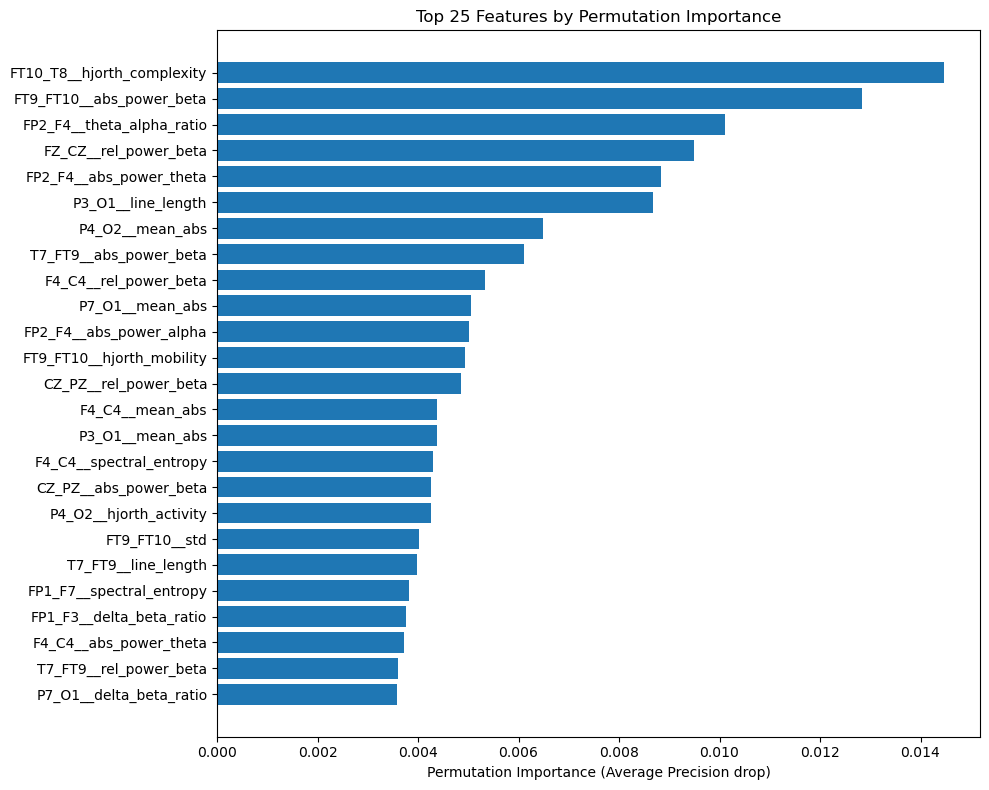

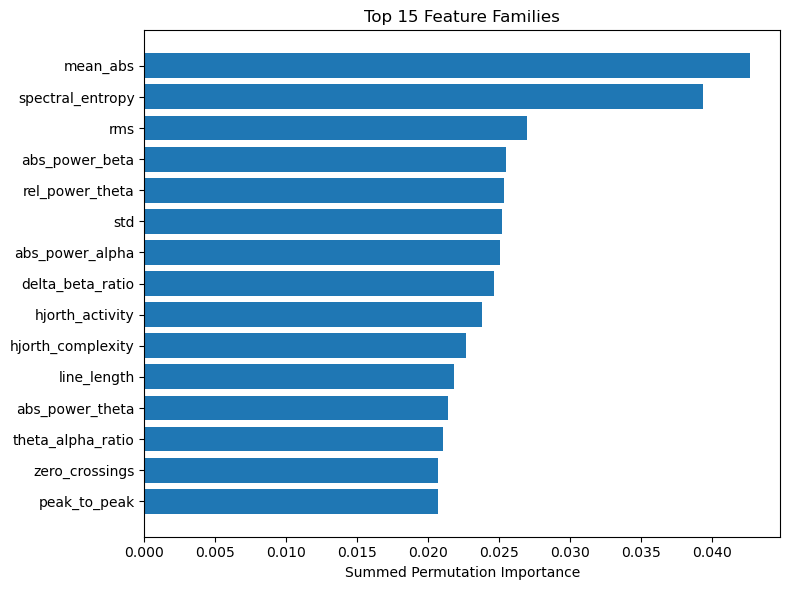

In [12]:
TOP_N_PLOT = min(25, len(importance_df))
top_plot_df = importance_df.head(TOP_N_PLOT).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_plot_df["feature"], top_plot_df["perm_mean"])
plt.title(f"Top {TOP_N_PLOT} Features by Permutation Importance")
plt.xlabel("Permutation Importance (Average Precision drop)")
plt.tight_layout()
plt.show()

TOP_N_FAMILY = min(15, len(family_importance_df))
top_family_df = family_importance_df.head(TOP_N_FAMILY).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_family_df["feature_family"], top_family_df["perm_mean"])
plt.title(f"Top {TOP_N_FAMILY} Feature Families")
plt.xlabel("Summed Permutation Importance")
plt.tight_layout()
plt.show()

## Block 9 — 基于重要性的特征取舍与重训 / Feature Selection, Keep-vs-Drop, and Retraining

这里采用一个简单且实用的策略：

- 先按 **permutation importance** 排序
- 取前 `TOP_K_FEATURES`
- 用这些特征重新训练 Random Forest
- 再和“全特征模型”对比

你之后可以把 `TOP_K_FEATURES` 改大/改小，观察性能和特征数之间的 trade-off。

In [13]:
def select_top_k_features(importance_df: pd.DataFrame, top_k: int) -> Tuple[List[str], List[str], pd.DataFrame]:
    """
    Use permutation importance ranking for keep/drop decision.
    """
    ranked = importance_df.sort_values(
        ["perm_mean", "mdi_importance"],
        ascending=False
    ).reset_index(drop=True)

    top_k = min(top_k, len(ranked))
    keep_features = ranked.loc[:top_k - 1, "feature"].tolist()
    drop_features = ranked.loc[top_k:, "feature"].tolist()

    selection_df = ranked.copy()
    selection_df["decision"] = np.where(selection_df["feature"].isin(keep_features), "keep", "drop")
    selection_df["rank"] = np.arange(1, len(selection_df) + 1)

    return keep_features, drop_features, selection_df


selected_features, dropped_features, selection_df = select_top_k_features(
    importance_df=importance_df,
    top_k=TOP_K_FEATURES
)

selection_df.to_csv(os.path.join(OUTPUT_DIR, "feature_selection_keep_drop.csv"), index=False)

print(f"Selected {len(selected_features)} features.")
print("\nTop kept features:")
display(selection_df[selection_df["decision"] == "keep"].head(20))

print("\nExample dropped features:")
display(selection_df[selection_df["decision"] == "drop"].head(20))

# Retrain RF using selected features only
X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

rf_sel = build_rf_model()
rf_sel.fit(X_train_sel, y_train)

if hasattr(rf_sel, "oob_decision_function_") and rf_sel.oob_decision_function_ is not None:
    if rf_sel.oob_decision_function_.shape[1] >= 2:
        train_oob_prob_sel = rf_sel.oob_decision_function_[:, 1]
    else:
        train_oob_prob_sel = np.full(len(y_train), np.nan)
else:
    train_oob_prob_sel = np.full(len(y_train), np.nan)

best_thr_sel = choose_threshold_by_best_f1(y_train, train_oob_prob_sel)
test_prob_sel = rf_sel.predict_proba(X_test_sel)[:, 1]
selected_metrics = evaluate_binary_predictions(y_test, test_prob_sel, best_thr_sel)

comparison_df = pd.DataFrame(
    [baseline_metrics, selected_metrics],
    index=["RF_all_features", f"RF_top_{len(selected_features)}"]
)

comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
display(comparison_df)

Selected 60 features.

Top kept features:


,feature,mdi_importance,perm_mean,perm_std,channel,feature_family,agg,perm_scoring_used,decision,rank
0,FT10_T8__hjorth_complexity,0.000585,0.014461,5.586438e-03,FT10_T8,hjorth_complexity,None,average_precision,keep,1
1,FT9_FT10__abs_power_beta,0.003163,0.012837,2.024126e-02,FT9_FT10,abs_power_beta,None,average_precision,keep,2
2,FP2_F4__theta_alpha_ratio,0.000060,0.010112,7.603560e-04,FP2_F4,theta_alpha_ratio,None,average_precision,keep,3
3,FZ_CZ__rel_power_beta,0.000948,0.009485,3.282322e-03,FZ_CZ,rel_power_beta,None,average_precision,keep,4
4,FP2_F4__abs_power_theta,0.000027,0.008830,2.613620e-04,FP2_F4,abs_power_theta,None,average_precision,keep,5
5,P3_O1__line_length,0.001620,0.008684,1.134981e-02,P3_O1,line_length,None,average_precision,keep,6
6,P4_O2__mean_abs,0.001065,0.006495,4.104048e-03,P4_O2,mean_abs,None,average_precision,keep,7
7,T7_FT9__abs_power_beta,0.000538,0.006117,7.080358e-03,T7_FT9,abs_power_beta,None,average_precision,keep,8
8,F4_C4__rel_power_beta,0.000635,0.005331,2.097482e-03,F4_C4,rel_power_beta,None,average_precision,keep,9
9,P7_O1__mean_abs,0.003033,0.005056,3.023016e-03,P7_O1,mean_abs,None,average_precision,keep,10



Example dropped features:


,feature,mdi_importance,perm_mean,perm_std,channel,feature_family,agg,perm_scoring_used,decision,rank
60,FZ_CZ__abs_power_theta,0.006933,0.002367,0.002256,FZ_CZ,abs_power_theta,None,average_precision,drop,61
61,C3_P3__abs_power_theta,0.002311,0.002358,0.001609,C3_P3,abs_power_theta,None,average_precision,drop,62
62,FZ_CZ__rel_power_theta,0.000479,0.002358,0.002124,FZ_CZ,rel_power_theta,None,average_precision,drop,63
63,ALL__spectral_entropy__max,0.000407,0.002345,0.002638,ALL,spectral_entropy,max,average_precision,drop,64
64,FZ_CZ__hjorth_activity,0.000451,0.002340,0.002489,FZ_CZ,hjorth_activity,None,average_precision,drop,65
65,T7_P7__spectral_entropy,0.002196,0.002328,0.000342,T7_P7,spectral_entropy,None,average_precision,drop,66
66,C3_P3__hjorth_mobility,0.000378,0.002288,0.002915,C3_P3,hjorth_mobility,None,average_precision,drop,67
67,C4_P4__zero_crossings,0.000100,0.002271,0.000930,C4_P4,zero_crossings,None,average_precision,drop,68
68,FZ_CZ__delta_beta_ratio,0.000391,0.002262,0.002167,FZ_CZ,delta_beta_ratio,None,average_precision,drop,69
69,T7_P7__abs_power_delta,0.000211,0.002242,0.000514,T7_P7,abs_power_delta,None,average_precision,drop,70


,threshold,auc,average_precision,precision,recall,specificity,f1,tn,fp,fn,tp
RF_all_features,0.454843,0.999548,0.864595,0.857143,0.652174,0.999747,0.740741,19749,5,16,30
RF_top_60,0.395525,0.999101,0.918034,0.923077,0.782609,0.999848,0.847059,19751,3,10,36


## Block 10 — Family-Level Keep-Drop Recommendation

In [14]:
family_selection_df = (
    selection_df
    .groupby("feature_family", as_index=False)
    .agg(
        n_total=("feature", "size"),
        n_keep=("decision", lambda s: int((s == "keep").sum())),
        mdi_importance=("mdi_importance", "sum"),
        perm_mean=("perm_mean", "sum"),
    )
    .sort_values(["perm_mean", "mdi_importance"], ascending=False)
    .reset_index(drop=True)
)

family_selection_df["keep_ratio"] = family_selection_df["n_keep"] / family_selection_df["n_total"]

# 简单规则:
# - keep_ratio >= 0.5: 推荐保留
# - 0 < keep_ratio < 0.5: 可选，建议继续实验
# - keep_ratio == 0: 当前模型里可以优先考虑删除
family_selection_df["recommendation"] = np.select(
    [
        family_selection_df["keep_ratio"] >= 0.5,
        (family_selection_df["keep_ratio"] > 0) & (family_selection_df["keep_ratio"] < 0.5),
        family_selection_df["keep_ratio"] == 0,
    ],
    [
        "KEEP",
        "MAYBE",
        "DROP_FIRST",
    ],
    default="MAYBE"
)

family_selection_df.to_csv(os.path.join(OUTPUT_DIR, "family_level_recommendation.csv"), index=False)

display(family_selection_df)

print("\nRecommended KEEP families:")
display(family_selection_df[family_selection_df["recommendation"] == "KEEP"])

print("\nRecommended DROP_FIRST families:")
display(family_selection_df[family_selection_df["recommendation"] == "DROP_FIRST"])

,feature_family,n_total,n_keep,mdi_importance,perm_mean,keep_ratio,recommendation
0,mean_abs,26,8,0.134503,0.042649,0.307692,MAYBE
1,spectral_entropy,26,5,0.114035,0.039391,0.192308,MAYBE
2,rms,26,5,0.050393,0.026924,0.192308,MAYBE
3,abs_power_beta,26,4,0.011763,0.025440,0.153846,MAYBE
4,rel_power_theta,26,3,0.073608,0.025348,0.115385,MAYBE
5,std,26,4,0.088146,0.025161,0.153846,MAYBE
6,abs_power_alpha,26,3,0.018725,0.025024,0.115385,MAYBE
7,delta_beta_ratio,26,3,0.005761,0.024626,0.115385,MAYBE
8,hjorth_activity,26,3,0.054257,0.023777,0.115385,MAYBE
9,hjorth_complexity,26,3,0.008124,0.022670,0.115385,MAYBE



Recommended KEEP families:


,feature_family,n_total,n_keep,mdi_importance,perm_mean,keep_ratio,recommendation



Recommended DROP_FIRST families:


,feature_family,n_total,n_keep,mdi_importance,perm_mean,keep_ratio,recommendation
17,abs_power_delta,26,0,0.003326,0.019134,0.0,DROP_FIRST
18,rel_power_alpha,26,0,0.010157,0.013448,0.0,DROP_FIRST


## Block 11 — Probability Plot for One Test File

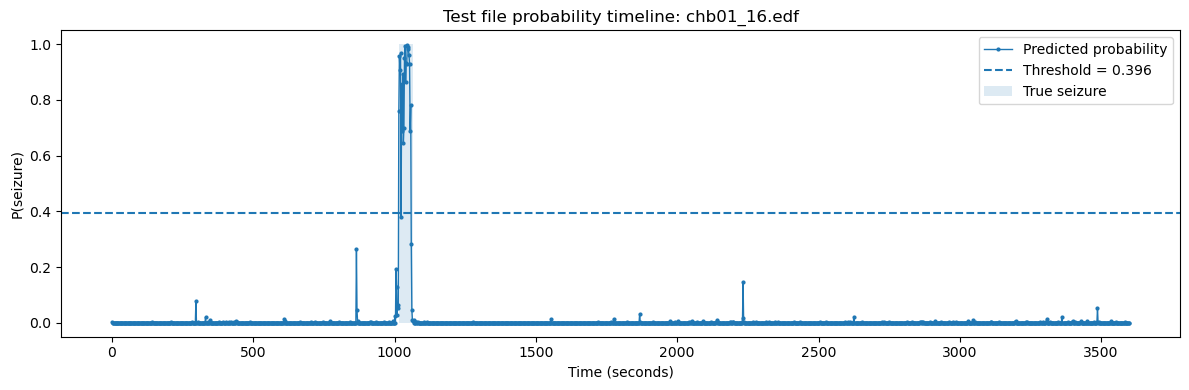

In [15]:
def plot_test_probability_for_file(
    meta_test: pd.DataFrame,
    y_test: np.ndarray,
    y_prob: np.ndarray,
    threshold: float,
    file_name: Optional[str] = None,
):
    """
    Plot predicted probabilities and ground-truth labels for one test EDF file.
    """
    plot_df = meta_test.copy()
    plot_df["y_true"] = y_test
    plot_df["y_prob"] = y_prob
    plot_df["y_pred"] = (y_prob >= threshold).astype(int)

    if file_name is None:
        tmp = (
            plot_df.groupby("file_name", as_index=False)["y_true"]
            .sum()
            .sort_values("y_true", ascending=False)
        )
        file_name = tmp.iloc[0]["file_name"]

    sub = plot_df.loc[plot_df["file_name"] == file_name].copy()
    if sub.empty:
        print(f"No test rows found for file: {file_name}")
        return

    t_mid = (sub["epoch_start_s"].to_numpy() + sub["epoch_end_s"].to_numpy()) / 2.0

    plt.figure(figsize=(12, 4))
    plt.plot(t_mid, sub["y_prob"].to_numpy(), marker="o", markersize=2, linewidth=1, label="Predicted probability")
    plt.axhline(threshold, linestyle="--", linewidth=1.5, label=f"Threshold = {threshold:.3f}")
    plt.fill_between(t_mid, 0, 1, where=sub["y_true"].to_numpy().astype(bool), alpha=0.15, label="True seizure")
    plt.xlabel("Time (seconds)")
    plt.ylabel("P(seizure)")
    plt.title(f"Test file probability timeline: {file_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


if len(meta_test) > 0:
    plot_test_probability_for_file(
        meta_test=meta_test,
        y_test=y_test,
        y_prob=test_prob_sel,
        threshold=best_thr_sel,
        file_name=None,
    )

## Block 12 — 结论与下一步 / What to Look At Next

你现在最应该关注 4 个输出：

1. `comparison_df`  
   看“全特征 vs 筛选后特征”的性能变化。

2. `importance_df`  
   看单个特征的重要性排序。

3. `family_selection_df`  
   看**哪类特征**值得保留，例如：
   - `line_length`
   - `hjorth_*`
   - `rel_power_*`
   - `spectral_entropy`

4. `OUTPUT_DIR` 下导出的 CSV  
   方便你之后做进一步筛选、对比实验或者写报告。

### 建议下一步
- 先观察 top features 是否集中在少数几个 family 上
- 如果某一类特征长期排在前面，可以只保留那一类再做实验
- 如果 `RF_top_k` 和 `RF_all_features` 性能接近，说明可以显著降维
- 后面如果你想，我可以继续帮你把这个 notebook 再扩展成：
  - 单病人 train/val/test 三分
  - 多病人版本
  - LOOCV 版本
  - 加 SHAP 分析版本